In [2]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNEL = 3
EPOCHS = 35

In [5]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
directory='D:\PROJECTS\Potato Disease Classification\Training\Potato Disease Dataset',
seed=42,
shuffle = True,
image_size=(IMAGE_SIZE,IMAGE_SIZE),
batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [54]:
class_names = dataset.class_names
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [55]:

for image_batch,label_batch in dataset.take(1):
    print("Image Batch Shape : ", image_batch.shape)
    print("Single Image : ", image_batch[0])
    print("Label Image numpy : ", label_batch.numpy)

Image Batch Shape :  (32, 256, 256, 3)
Single Image :  tf.Tensor(
[[[124. 122. 136.]
  [134. 132. 146.]
  [146. 144. 158.]
  ...
  [187. 189. 201.]
  [188. 190. 202.]
  [189. 191. 203.]]

 [[140. 138. 152.]
  [105. 103. 117.]
  [136. 134. 148.]
  ...
  [186. 188. 200.]
  [188. 190. 202.]
  [189. 191. 203.]]

 [[163. 161. 175.]
  [136. 134. 148.]
  [140. 138. 152.]
  ...
  [187. 189. 201.]
  [188. 190. 202.]
  [189. 191. 203.]]

 ...

 [[131. 129. 142.]
  [142. 140. 153.]
  [141. 139. 152.]
  ...
  [193. 195. 208.]
  [192. 194. 207.]
  [191. 193. 206.]]

 [[145. 143. 156.]
  [152. 150. 163.]
  [135. 133. 146.]
  ...
  [194. 196. 209.]
  [193. 195. 208.]
  [191. 193. 206.]]

 [[130. 128. 141.]
  [141. 139. 152.]
  [130. 128. 141.]
  ...
  [193. 195. 208.]
  [192. 194. 207.]
  [191. 193. 206.]]], shape=(256, 256, 3), dtype=float32)
Label Image numpy :  <bound method _EagerTensorBase.numpy of <tf.Tensor: shape=(32,), dtype=int32, numpy=
array([1, 2, 1, 1, 2, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0

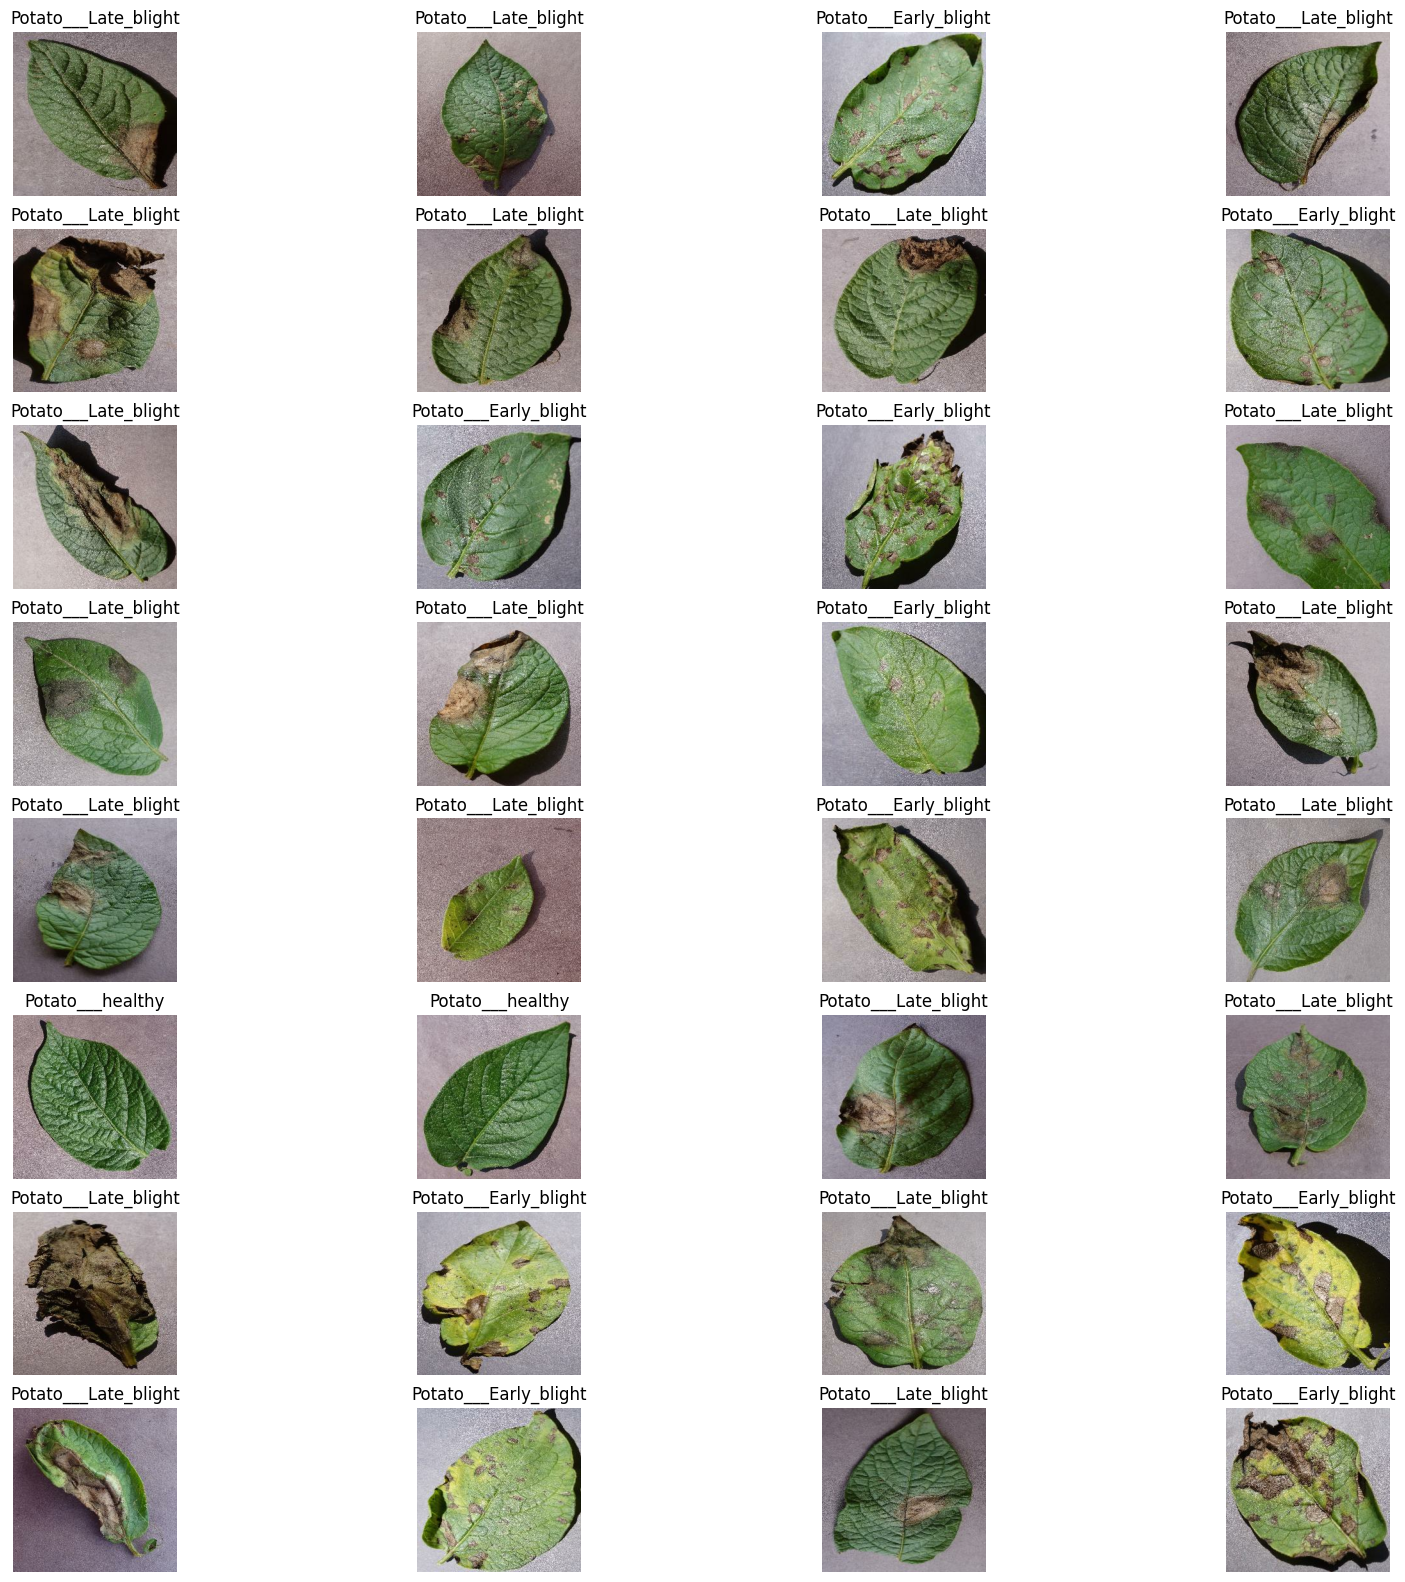

In [56]:
plt.figure(figsize=(20, 20))
for image_batch, labels_batch in dataset.take(1):
    for i in range(32):
        ax = plt.subplot(8, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

In [57]:
print(len(dataset))

68


In [58]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    
    dataset_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=42)
    
    train_size = int(train_split * dataset_size)
    val_size = int(val_split * dataset_size)
    
    train_ds = ds.take(train_size)    
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [59]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [60]:
print(f"Lenght of Training : {len(train_ds)}\nLength of Testing : {len(test_ds)}\nLength of Valdidation : {len(val_ds)}")

Lenght of Training : 54
Length of Testing : 8
Length of Valdidation : 6


In [61]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [62]:
resize_and_rescale = tf.keras.Sequential([
  layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.experimental.preprocessing.Rescaling(1./255),
])

In [63]:
data_augmentation = tf.keras.Sequential([
  layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
  layers.experimental.preprocessing.RandomRotation(0.2),
])

In [64]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [65]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNEL)
n_classes = 3

model = models.Sequential([
    resize_and_rescale,
    layers.Conv2D(32, kernel_size = (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

model.build(input_shape=input_shape)

In [66]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_3 (Sequential)   (32, 256, 256, 3)         0         
                                                                 
 conv2d_6 (Conv2D)           (32, 254, 254, 32)        896       
                                                                 
 max_pooling2d_6 (MaxPooling  (32, 127, 127, 32)       0         
 2D)                                                             
                                                                 
 conv2d_7 (Conv2D)           (32, 125, 125, 64)        18496     
                                                                 
 max_pooling2d_7 (MaxPooling  (32, 62, 62, 64)         0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (32, 60, 60, 64)         

In [67]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [68]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS,
)

Epoch 1/35
54/54 [==============================] - 12s 174ms/step - loss: 0.9004 - accuracy: 0.4724 - val_loss: 0.7735 - val_accuracy: 0.5469
Epoch 2/35
54/54 [==============================] - 8s 148ms/step - loss: 0.7177 - accuracy: 0.6408 - val_loss: 0.5259 - val_accuracy: 0.7917
Epoch 3/35
54/54 [==============================] - 8s 146ms/step - loss: 0.5458 - accuracy: 0.7459 - val_loss: 0.4435 - val_accuracy: 0.8229
Epoch 4/35
54/54 [==============================] - 8s 147ms/step - loss: 0.4154 - accuracy: 0.8257 - val_loss: 0.2855 - val_accuracy: 0.8958
Epoch 5/35
54/54 [==============================] - 8s 148ms/step - loss: 0.3532 - accuracy: 0.8539 - val_loss: 0.3262 - val_accuracy: 0.8854
Epoch 6/35
54/54 [==============================] - 8s 149ms/step - loss: 0.3202 - accuracy: 0.8756 - val_loss: 0.2227 - val_accuracy: 0.9219
Epoch 7/35
54/54 [==============================] - 8s 149ms/step - loss: 0.1787 - accuracy: 0.9343 - val_loss: 0.1464 - val_accuracy: 0.9375
Epoch

In [69]:
scores = model.evaluate(test_ds)

8/8 [==============================] - 1s 32ms/step - loss: 0.0833 - accuracy: 0.9766


In [70]:
model.save("model.keras")

In [71]:
print(history)
print(history.params)
print(history.history.keys())

{'verbose': 1, 'epochs': 35, 'steps': 54}
dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


In [72]:
history.history['loss'][:10] # show loss for first 5 epochs

[0.9004193544387817,
 0.7177252769470215,
 0.5457741022109985,
 0.4154384136199951,
 0.35322901606559753,
 0.32016322016716003,
 0.17869578301906586,
 0.1551526039838791,
 0.12010448426008224,
 0.08563099056482315]

In [73]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

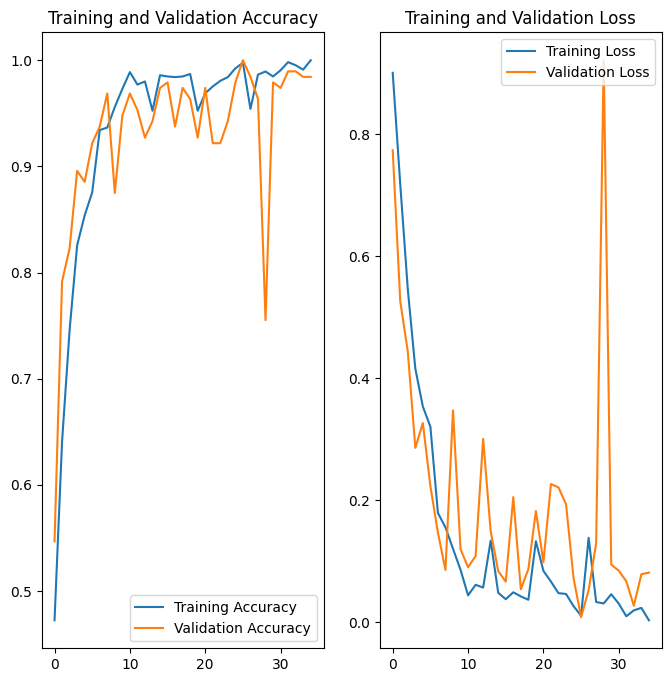

In [74]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()